# Taller B4-T1 - Diseño de Redes Confiables

## Punto 1: arquitectura customizada con ratio de endeudamiento

Este notebook implementa **solo el primer punto de la práctica**: una arquitectura de red neuronal que incorpora una capa customizada para calcular ratios financieros internos antes de alimentar las capas densas.

El objetivo no es todavía resolver la parte completa de justicia, incertidumbre o comparación entre modelos, sino construir una base fiable y trazable sobre la que después se podrán añadir FAIR loss, AutoML, estimación de incertidumbre y análisis de Pareto.

## Objetivo de este notebook

Vamos a trabajar con el dataset `application_train.csv` de Home Credit Default Risk y construiremos un modelo binario para predecir `TARGET`:

- `TARGET = 1`: cliente con dificultades de pago.
- `TARGET = 0`: cliente sin dificultades de pago.

La aportación principal de esta primera versión es la capa `DebtBurdenLayer`, que calcula dentro del modelo dos indicadores financieros interpretables:

- cuota anual sobre ingresos: `AMT_ANNUITY / AMT_INCOME_TOTAL`;
- crédito total sobre ingresos: `AMT_CREDIT / AMT_INCOME_TOTAL`.

Estos ratios se calculan con variables monetarias en bruto, no con variables escaladas, para conservar su significado económico.

In [13]:
# Imports generales para manipulación de datos, modelado y evaluación.
# Se agrupan al inicio para que el notebook sea fácil de ejecutar de arriba abajo.

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

# Semillas para mejorar la reproducibilidad. En redes neuronales no garantiza
# resultados idénticos en todos los entornos, pero reduce variabilidad accidental.
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH = "application_train.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Por qué no usamos `CODE_GENDER` como entrada

`CODE_GENDER` se trata como **variable sensible**. La guardamos aparte porque será necesaria para auditar diferencias entre grupos y, más adelante, para diseñar o evaluar restricciones de justicia.

En esta primera arquitectura no se incluye como entrada directa del modelo. De este modo evitamos que la red utilice explícitamente el género para optimizar la predicción. Esto no garantiza justicia por sí solo, porque otras variables pueden contener información correlacionada con el género, pero deja preparada una separación clara entre:

- variables predictoras usadas por la red;
- variable sensible usada para auditoría y futuras pérdidas FAIR.

## Carga y preprocesado de datos

La función `load_home_credit_data` realiza un preprocesado cuidadoso y evita fugas de información entre entrenamiento, validación y test:

- lee únicamente las columnas necesarias para este punto;
- elimina los casos `CODE_GENDER == "XNA"`;
- convierte `CODE_GENDER` a una variable binaria sensible (`M -> 0`, `F -> 1`);
- transforma `DAYS_BIRTH` en edad positiva en años;
- separa `y`, `s` y las variables de entrada del modelo;
- crea dos ramas de entrada: una escalada y otra financiera en bruto;
- separa explícitamente `train`, `validation` y `test`;
- ajusta imputador y escalador solo con `train`;
- aplica esas transformaciones a `validation` y `test` sin recalcular parámetros.

In [14]:
def load_home_credit_data(file_path):
    """Carga y prepara los datos de Home Credit para la arquitectura customizada.

    La función devuelve tres subconjuntos separados: train, validation y test.
    Cada subconjunto contiene:
    1. variables predictoras imputadas y escaladas;
    2. variables financieras imputadas en bruto, sin escalar;
    3. etiqueta binaria `TARGET` en formato float32 para Keras;
    4. variable sensible `CODE_GENDER` conservada aparte para auditoría.

    La rama financiera se mantiene en escala monetaria real porque los ratios de
    `DebtBurdenLayer` deben calcularse sobre importes originales o imputados, no
    sobre z-scores.
    """

    selected_cols = [
        "TARGET",
        "CODE_GENDER",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "DAYS_BIRTH",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]

    df = pd.read_csv(file_path, usecols=selected_cols)
    df = df.loc[df["CODE_GENDER"] != "XNA"].copy()

    # Flags de missingness calculados antes de imputar. No entran todavía como
    # inputs del modelo, pero quedan disponibles para incertidumbre y auditoría.
    ext_source_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    missing_flag_cols = [f"{col}_missing" for col in ext_source_cols]
    ext_source_missing_flags = df[ext_source_cols].isna().astype("int32")
    ext_source_missing_flags.columns = missing_flag_cols

    ext_source_missingness_summary = pd.DataFrame(
        {
            "variable": ext_source_cols,
            "missing_count": df[ext_source_cols].isna().sum().to_numpy(),
            "missing_rate": df[ext_source_cols].isna().mean().to_numpy(),
        }
    )

    # Variable sensible codificada y conservada fuera del input del modelo.
    df["CODE_GENDER"] = df["CODE_GENDER"].map({"M": 0, "F": 1}).astype(int)

    # Edad positiva en años. La columna original se elimina para evitar duplicar
    # la misma información con dos escalas distintas.
    df["AGE_YEARS"] = np.abs(df["DAYS_BIRTH"]) / 365.25
    df = df.drop(columns=["DAYS_BIRTH"])

    scaled_features = [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AGE_YEARS",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]
    financial_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

    X = df[scaled_features].copy()
    y = df["TARGET"].astype(int)
    s = df["CODE_GENDER"].astype(int)

    # Primer split: separamos test y no lo tocamos durante entrenamiento ni
    # selección de hiperparámetros.
    (
        X_trainval,
        X_test,
        missing_trainval,
        missing_test,
        y_trainval,
        y_test,
        s_trainval,
        s_test,
    ) = train_test_split(
        X,
        ext_source_missing_flags,
        y,
        s,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Segundo split: separamos validation desde trainval. El reparto final queda
    # aproximadamente en 64 % train, 16 % validation y 20 % test.
    (
        X_train,
        X_val,
        missing_train,
        missing_val,
        y_train,
        y_val,
        s_train,
        s_val,
    ) = train_test_split(
        X_trainval,
        missing_trainval,
        y_trainval,
        s_trainval,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_trainval,
    )

    # Imputación ajustada solo con train. Validation y test se transforman con el
    # mismo imputador para evitar data leakage.
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    X_val_imputed = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index,
    )
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index,
    )

    # Rama financiera: datos imputados, pero no escalados. Así los ratios internos
    # siguen teniendo interpretación económica.
    X_train_financial_raw = X_train_imputed[financial_features].astype("float32")
    X_val_financial_raw = X_val_imputed[financial_features].astype("float32")
    X_test_financial_raw = X_test_imputed[financial_features].astype("float32")

    # Rama principal: escalado ajustado solo con train.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imputed[scaled_features]),
        columns=scaled_features,
        index=X_train_imputed.index,
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_imputed[scaled_features]),
        columns=scaled_features,
        index=X_val_imputed.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imputed[scaled_features]),
        columns=scaled_features,
        index=X_test_imputed.index,
    )

    X_train_scaled_np = X_train_scaled.astype("float32")
    X_val_scaled_np = X_val_scaled.astype("float32")
    X_test_scaled_np = X_test_scaled.astype("float32")

    y_train_np = y_train.astype("float32").values
    y_val_np = y_val.astype("float32").values
    y_test_np = y_test.astype("float32").values

    preprocessor = {
        "feature_cols": scaled_features,
        "financial_cols": financial_features,
        "imputer": imputer,
        "medians": pd.Series(imputer.statistics_, index=scaled_features),
        "scaler": scaler,
        "missing_flag_cols": missing_flag_cols,
        "ext_source_missing_train": missing_train.reset_index(drop=True),
        "ext_source_missing_val": missing_val.reset_index(drop=True),
        "ext_source_missing_test": missing_test.reset_index(drop=True),
        "ext_source_missingness_summary": ext_source_missingness_summary,
    }

    return (
        X_train_scaled_np,
        X_train_financial_raw,
        y_train_np,
        s_train,
    ), (
        X_val_scaled_np,
        X_val_financial_raw,
        y_val_np,
        s_val,
    ), (
        X_test_scaled_np,
        X_test_financial_raw,
        y_test_np,
        s_test,
    ), preprocessor

## Split explícito train / validation / test

En esta versión sustituimos la partición automática de validación por un conjunto de validación explícito. Esto permite conservar también la variable sensible `CODE_GENDER` en validación (`s_val`), lo cual será necesario para la siguiente fase de la práctica: medir y penalizar la dependencia entre las predicciones del modelo y la variable sensible.

El conjunto de test se mantiene separado y no se usa durante el entrenamiento ni durante la selección de hiperparámetros.

Antes de entrenar el modelo conviene comprobar que las ramas tienen las formas esperadas y que las distribuciones principales se conservan tras el split.

In [15]:
(
    X_train_scaled_np,
    X_train_financial_raw,
    y_train_np,
    s_train,
), (
    X_val_scaled_np,
    X_val_financial_raw,
    y_val_np,
    s_val,
), (
    X_test_scaled_np,
    X_test_financial_raw,
    y_test_np,
    s_test,
), preprocessor = load_home_credit_data(DATA_PATH)

print("Shape de X_train_scaled_np:", X_train_scaled_np.shape)
print("Shape de X_val_scaled_np:", X_val_scaled_np.shape)
print("Shape de X_test_scaled_np:", X_test_scaled_np.shape)
print("Shape de X_train_financial_raw:", X_train_financial_raw.shape)
print("Shape de X_val_financial_raw:", X_val_financial_raw.shape)
print("Shape de X_test_financial_raw:", X_test_financial_raw.shape)
print("Shape de y_train_np:", y_train_np.shape)
print("Shape de y_val_np:", y_val_np.shape)
print("Shape de y_test_np:", y_test_np.shape)

print("\ns_train shape:", s_train.shape)
print("s_val shape:", s_val.shape)
print("s_test shape:", s_test.shape)

print("\nColumnas de la rama escalada:")
print(preprocessor["feature_cols"])

print("\nColumnas de la rama financiera en bruto:")
print(preprocessor["financial_cols"])

print("\nFlags de missingness preparados para análisis posterior:")
print(preprocessor["missing_flag_cols"])

missingness_path = OUTPUT_DIR / "ext_source_missingness_summary.csv"
preprocessor["ext_source_missingness_summary"].to_csv(missingness_path, index=False)
print(f"\nResumen de missingness guardado en: {missingness_path}")
display(preprocessor["ext_source_missingness_summary"])

Shape de X_train_scaled_np: (196804, 7)
Shape de X_val_scaled_np: (49201, 7)
Shape de X_test_scaled_np: (61502, 7)
Shape de X_train_financial_raw: (196804, 3)
Shape de X_val_financial_raw: (49201, 3)
Shape de X_test_financial_raw: (61502, 3)
Shape de y_train_np: (196804,)
Shape de y_val_np: (49201,)
Shape de y_test_np: (61502,)

s_train shape: (196804,)
s_val shape: (49201,)
s_test shape: (61502,)

Columnas de la rama escalada:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

Columnas de la rama financiera en bruto:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

Flags de missingness preparados para análisis posterior:
['EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']

Resumen de missingness guardado en: outputs\ext_source_missingness_summary.csv


,variable,missing_count,missing_rate
0,EXT_SOURCE_1,173376,0.563812
1,EXT_SOURCE_2,660,0.002146
2,EXT_SOURCE_3,60965,0.198256


In [16]:
# Distribución de TARGET en train, validation y test. normalize=True muestra
# proporciones, útil porque el problema está desbalanceado hacia la clase 0.
print("Distribución de TARGET en train:")
print(pd.Series(y_train_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en validation:")
print(pd.Series(y_val_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en test:")
print(pd.Series(y_test_np, name="TARGET").value_counts(normalize=True).sort_index())

# Distribución de la variable sensible. Esta información no se usa como input
# del modelo, pero se conserva para los siguientes puntos de justicia.
print("\nDistribución de CODE_GENDER en train (0=M, 1=F):")
print(s_train.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en validation (0=M, 1=F):")
print(s_val.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en test (0=M, 1=F):")
print(s_test.value_counts(normalize=True).sort_index())

Distribución de TARGET en train:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en validation:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en test:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64

Distribución de CODE_GENDER en train (0=M, 1=F):
CODE_GENDER
0    0.341939
1    0.658061
Name: proportion, dtype: float64

Distribución de CODE_GENDER en validation (0=M, 1=F):
CODE_GENDER
0    0.341578
1    0.658422
Name: proportion, dtype: float64

Distribución de CODE_GENDER en test (0=M, 1=F):
CODE_GENDER
0    0.340769
1    0.659231
Name: proportion, dtype: float64


### Interpretación del desbalance de clases

La variable objetivo está fuertemente desbalanceada. Aproximadamente el 92 % de los clientes pertenecen a la clase `TARGET = 0` y solo alrededor del 8 % pertenecen a la clase `TARGET = 1`.

Esto implica que la métrica `accuracy` debe interpretarse con cautela. Un modelo trivial que predijera siempre “buen pagador” obtendría una accuracy muy alta, pero no detectaría ningún cliente con dificultades de pago.

Por este motivo, en este problema son especialmente relevantes métricas como AUC, recall de la clase minoritaria, precision de la clase minoritaria y balanced accuracy.

In [17]:
# Primeras filas de la rama financiera en bruto. Deben verse como importes
# monetarios originales, no como variables centradas alrededor de cero.
X_train_financial_raw.head(10)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
1228,90000.0,203760.0,11826.0
162360,67500.0,180000.0,9000.0
68610,315000.0,1125000.0,44019.0
122818,225000.0,156384.0,16155.0
274639,135000.0,573628.5,24435.0
154292,211500.0,729567.0,27166.5
290325,180000.0,113076.0,5773.5
176690,112500.0,381528.0,22032.0
156479,67500.0,343800.0,16155.0
212749,121500.0,942300.0,30528.0


## Por qué calculamos ratios financieros en una capa customizada

Una red densa estándar puede aprender interacciones entre variables, pero no sabe de partida que ciertos cocientes financieros son especialmente relevantes.

La capa customizada introduce conocimiento previo del dominio:

- una cuota anual alta respecto a ingresos puede indicar mayor presión financiera;
- un crédito alto respecto a ingresos puede indicar mayor exposición al endeudamiento.

Al calcular estos ratios dentro del grafo de TensorFlow, la transformación queda integrada en el modelo, aparece en `model.summary()` y puede serializarse junto con la arquitectura.

## Flags de missingness para `EXT_SOURCE`

Las variables `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` tienen valores ausentes. En este punto los valores se imputan con medianas calculadas solo en train, pero además conservamos tres indicadores auxiliares:

- `EXT_SOURCE_1_missing`;
- `EXT_SOURCE_2_missing`;
- `EXT_SOURCE_3_missing`.

Estos flags valen 1 si el dato original estaba ausente y 0 si estaba informado. No se usan todavía como entrada de la arquitectura principal, pero quedan preparados para el análisis posterior de incertidumbre. El resumen de missingness se guarda en `outputs/ext_source_missingness_summary.csv`.

## Por qué se usa `tanh` como saturación

Los ratios financieros pueden tomar valores extremos cuando los ingresos son bajos o cuando el crédito es muy alto. Si se pasan directamente a la red, esos valores pueden dominar el entrenamiento.

Usamos `tanh` porque es una saturación suave y diferenciable:

- mantiene el entrenamiento compatible con backpropagation;
- comprime valores extremos;
- conserva una señal ordenada: ratios más altos producen salidas saturadas más altas;
- reduce el impacto de outliers sin aplicar cortes bruscos.

### Interpretación de la capa `DebtBurdenLayer`

La capa customizada introduce conocimiento financiero dentro de la arquitectura neuronal.

En lugar de dejar que la red aprenda desde cero todas las relaciones entre ingresos, crédito y anualidad, calculamos explícitamente dos ratios interpretables:

- cuota anual sobre ingresos;
- crédito total sobre ingresos.

Después aplicamos una saturación suave mediante `tanh`. Esta saturación evita que ratios extremos dominen el entrenamiento, pero conserva el orden económico de la señal: ratios más altos siguen generando valores más altos.

La capa no tiene parámetros entrenables. Su función es imponer una transformación financiera razonable antes de pasar la información a las capas densas.

In [18]:
class DebtBurdenLayer(tf.keras.layers.Layer):
    """Capa customizada para calcular ratios de endeudamiento saturados.

    La capa recibe tres columnas en este orden:
    [AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY]

    Devuelve dos columnas:
    1. `annuity_ratio_sat`: cuota anual sobre ingresos, saturada con tanh.
    2. `credit_ratio_sat`: crédito total sobre ingresos, saturado con tanh.
    """

    def __init__(self, annuity_tau=0.5, credit_tau=5.0, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.annuity_tau = annuity_tau
        self.credit_tau = credit_tau
        self.epsilon = epsilon

    def call(self, inputs):
        # Separación explícita de columnas. Usamos rangos como 0:1 para mantener
        # tensores bidimensionales de shape (batch_size, 1), lo que facilita la
        # concatenación posterior.
        income = inputs[:, 0:1]
        credit = inputs[:, 1:2]
        annuity = inputs[:, 2:3]

        # Ratios financieros sobre variables monetarias originales. epsilon evita
        # divisiones por cero si apareciera algún ingreso nulo.
        annuity_income_ratio = annuity / (income + self.epsilon)
        credit_income_ratio = credit / (income + self.epsilon)

        # Saturación suave. Los parámetros tau controlan la escala a partir de la
        # cual cada ratio empieza a acercarse a 1.
        annuity_ratio_sat = tf.math.tanh(annuity_income_ratio / self.annuity_tau)
        credit_ratio_sat = tf.math.tanh(credit_income_ratio / self.credit_tau)

        # El resultado final tiene dos columnas y puede concatenarse con la rama
        # principal de variables escaladas.
        return tf.concat([annuity_ratio_sat, credit_ratio_sat], axis=1)

    def get_config(self):
        # Permite guardar y recargar modelos que incluyan esta capa customizada.
        config = super().get_config()
        config.update(
            {
                "annuity_tau": self.annuity_tau,
                "credit_tau": self.credit_tau,
                "epsilon": self.epsilon,
            }
        )
        return config

## Comprobación de la capa customizada

Probamos `DebtBurdenLayer` sobre cinco ejemplos reales de la rama financiera. La salida debe tener dos columnas y valores aproximadamente entre 0 y 1, porque los importes son positivos y `tanh` satura por arriba.

In [19]:
# Instanciamos la capa de forma aislada para verificar su comportamiento antes
# de integrarla en el modelo funcional.
debt_layer_check = DebtBurdenLayer(name="debt_burden_layer_check")
ratio_examples = debt_layer_check(X_train_financial_raw.iloc[:5].to_numpy()).numpy()

ratio_check_df = pd.DataFrame(
    ratio_examples,
    columns=["annuity_ratio_sat", "credit_ratio_sat"],
)

print("Shape de la salida de DebtBurdenLayer:", ratio_examples.shape)
print("\nPrimeros ratios saturados:")
display(ratio_check_df)

print("\nMínimos por columna:")
print(ratio_check_df.min())

print("\nMáximos por columna:")
print(ratio_check_df.max())

Shape de la salida de DebtBurdenLayer: (5, 2)

Primeros ratios saturados:


,annuity_ratio_sat,credit_ratio_sat
0,0.256913,0.424198
1,0.260520,0.487925
2,0.272429,0.613357
3,0.142621,0.138120
4,0.346974,0.690975



Mínimos por columna:
annuity_ratio_sat    0.142621
credit_ratio_sat     0.138120
dtype: float32

Máximos por columna:
annuity_ratio_sat    0.346974
credit_ratio_sat     0.690975
dtype: float32


## Modelo funcional con dos entradas

La red tiene dos ramas de entrada:

- `scaled_features`: siete variables imputadas y escaladas;
- `financial_raw`: tres variables monetarias imputadas sin escalar.

La capa `DebtBurdenLayer` transforma la rama financiera en dos ratios saturados. Después concatenamos esos dos ratios con las siete variables escaladas y entrenamos capas densas para la clasificación binaria.

In [20]:
def build_custom_debt_model(n_scaled_features):
    """Construye el modelo Keras funcional con la capa DebtBurdenLayer."""

    # Entrada principal: variables numéricas ya imputadas y estandarizadas.
    scaled_input = keras.Input(
        shape=(n_scaled_features,),
        name="scaled_features",
    )

    # Entrada financiera: importes originales imputados, sin escalar. Esta rama
    # existe exclusivamente para calcular ratios interpretables dentro del modelo.
    financial_raw_input = keras.Input(
        shape=(3,),
        name="financial_raw",
    )

    # Capa customizada solicitada en la práctica. Debe aparecer en model.summary().
    ratios = DebtBurdenLayer(name="debt_burden_layer")(financial_raw_input)

    # Unimos las variables escaladas con los ratios financieros calculados por
    # la red. El tensor resultante tiene 7 + 2 = 9 variables.
    x = layers.Concatenate(name="concat_scaled_and_custom_ratios")(
        [scaled_input, ratios]
    )

    # Bloque denso sencillo. BatchNormalization ayuda a estabilizar activaciones
    # intermedias; Dropout reduce sobreajuste en una tabla con muchas filas.
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.BatchNormalization(name="batch_norm_64")(x)
    x = layers.Dropout(0.25, name="dropout_025")(x)

    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    x = layers.Dropout(0.15, name="dropout_015")(x)

    # Salida binaria: probabilidad estimada de TARGET = 1.
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)

    model = keras.Model(
        inputs=[scaled_input, financial_raw_input],
        outputs=output,
        name="home_credit_custom_debt_model",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model


model = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
model.summary()

Model: "home_credit_custom_debt_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ financial_raw       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_features     │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ debt_burden_layer   │ (None, 2)         │          0 │ financial_raw[0]… │
│ (DebtBurdenLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_scaled_and_… │ (None, 9)         │          0 │ scaled_features[… │
│ (Concatenate)       │                   │            │ debt_burden_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │        640 │ concat_scaled_an… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_64       │ (None, 64)        │        256 │ dense_64[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_025         │ (None, 64)        │          0 │ batch_norm_64[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dropout_025[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_015         │ (None, 32)        │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ default_probability │ (None, 1)         │         33 │ dropout_015[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 128 (512.00 B)

## Entrenamiento

`TARGET` está desbalanceada: hay muchos más buenos pagadores que clientes con dificultades. Para compensarlo, calculamos `class_weight` con sklearn y lo pasamos a `model.fit`.

También usamos dos callbacks:

- `EarlyStopping`, para recuperar los mejores pesos según `val_auc`;
- `ReduceLROnPlateau`, para reducir la tasa de aprendizaje si `val_auc` deja de mejorar.

In [21]:
# Pesos de clase calculados solo con y_train. El objetivo es que la clase
# minoritaria tenga más peso durante la optimización.
classes = np.unique(y_train_np.astype(int))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np.astype(int),
)

# Conversión explícita a tipos nativos de Python para evitar impresiones como
# np.int64(0) o np.float64(...), y para mantener compatibilidad clara con Keras.
class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:", class_weight)

EPOCHS = 100
BATCH_SIZE = 1024

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = model.fit(
    x={
        "scaled_features": X_train_scaled_np,
        "financial_raw": X_train_financial_raw,
    },
    y=y_train_np,
    validation_data=(
        {
            "scaled_features": X_val_scaled_np,
            "financial_raw": X_val_financial_raw,
        },
        y_val_np,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Class weights: {0: 0.5439098808286719, 1: 6.193479355488419}
Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6427 - auc: 0.6856 - loss: 0.6519 - val_accuracy: 0.6424 - val_auc: 0.7233 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6524 - auc: 0.7112 - loss: 0.6242 - val_accuracy: 0.6621 - val_auc: 0.7259 - val_loss: 0.6188 - learning_rate: 0.0010
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6605 - auc: 0.7191 - loss: 0.6179 - val_accuracy: 0.6578 - val_auc: 0.7263 - val_loss: 0.6167 - learning_rate: 0.0010
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6582 - auc: 0.7208 - loss: 0.6161 - val_accuracy: 0.6567 - val_auc: 0.7272 - val_loss: 0.6132 - learning_rate: 0.0010
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6607 - auc: 0.7225 - loss: 0.6148 - val_accuracy: 0.6578 - val_auc: 0.7268 - val_loss: 0.6098 - learning_rate: 0.0010
Epoch 6/100
19

## Curvas de entrenamiento

Las curvas permiten comprobar visualmente si el modelo aprende y si aparece sobreajuste. En esta práctica nos interesan especialmente:

- `loss` y `val_loss`, para ver la evolución de la función de coste;
- `auc` y `val_auc`, porque AUC es más informativa que accuracy cuando la clase positiva es minoritaria.

Histórico de entrenamiento guardado en: outputs\training_history_punto1_custom_layer.csv


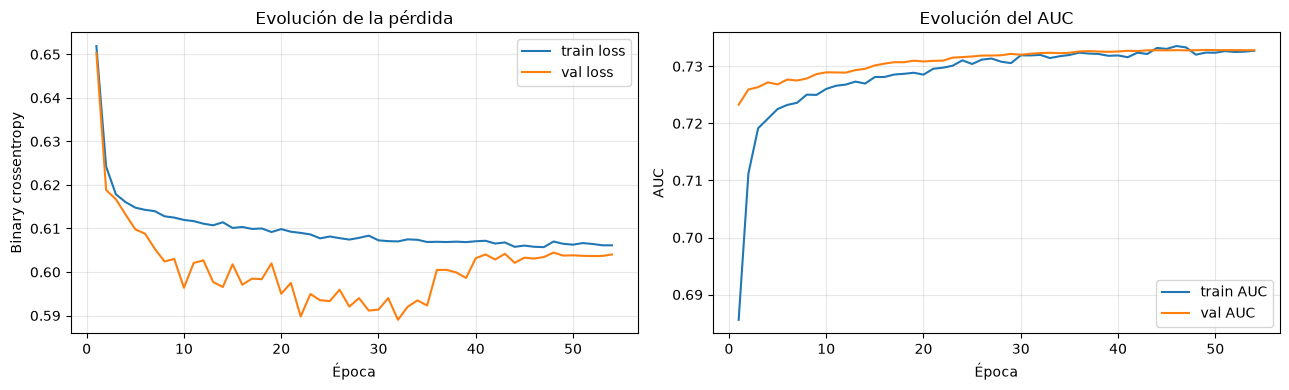

In [22]:
def plot_training_curves(history):
    """Dibuja curvas de loss y AUC para entrenamiento y validación."""

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    history_path = OUTPUT_DIR / "training_history_punto1_custom_layer.csv"
    history_df.to_csv(history_path, index=False)
    print(f"Histórico de entrenamiento guardado en: {history_path}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["epoch"], history_df["loss"], label="train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    axes[0].set_title("Evolución de la pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Binary crossentropy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["auc"], label="train AUC")
    axes[1].plot(history_df["epoch"], history_df["val_auc"], label="val AUC")
    axes[1].set_title("Evolución del AUC")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## Evaluación en test

Evaluamos sobre el subconjunto de test que no se ha usado para ajustar medianas, escalador ni pesos del modelo. Calculamos métricas básicas de clasificación y guardamos probabilidades para análisis posteriores.

In [23]:
# Evaluación nativa de Keras con las métricas definidas en compile. Se evalúa
# exclusivamente sobre test, que no se ha usado ni para entrenar ni para validar.
test_metrics = model.evaluate(
    x={
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    y=y_test_np,
    batch_size=1024,
    verbose=0,
    return_dict=True,
)

print("Métricas de test devueltas por Keras:")
print(test_metrics)

# Probabilidades de clase positiva sobre test. El umbral 0.5 se usa solo para
# obtener una predicción binaria sencilla; más adelante podría calibrarse o
# ajustarse por objetivos de justicia/riesgo.
y_test_proba = model.predict(
    {
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    batch_size=1024,
    verbose=0,
).ravel()

y_test_pred = (y_test_proba >= 0.5).astype(int)

auc_test = roc_auc_score(y_test_np, y_test_proba)
accuracy_test = accuracy_score(y_test_np, y_test_pred)
balanced_accuracy_test = balanced_accuracy_score(y_test_np, y_test_pred)
precision_class_1, recall_class_1, f1_class_1, _ = precision_recall_fscore_support(
    y_test_np,
    y_test_pred,
    labels=[1],
    zero_division=0,
)
conf_matrix = confusion_matrix(y_test_np, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = conf_matrix.ravel()

print(f"AUC test: {auc_test:.4f}")
print(f"Accuracy test con threshold 0.5: {accuracy_test:.4f}")
print(f"Balanced accuracy test con threshold 0.5: {balanced_accuracy_test:.4f}")

print("\nMatriz de confusión:")
print(conf_matrix)

print("\nClassification report:")
print(classification_report(y_test_np, y_test_pred, digits=4, zero_division=0))

metrics_punto1 = pd.DataFrame(
    [
        {
            "test_auc": auc_test,
            "test_accuracy": accuracy_test,
            "balanced_accuracy": balanced_accuracy_test,
            "recall_class_1": recall_class_1[0],
            "precision_class_1": precision_class_1[0],
            "f1_class_1": f1_class_1[0],
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    ]
)

metrics_path = OUTPUT_DIR / "metrics_punto1_custom_layer.csv"
metrics_punto1.to_csv(metrics_path, index=False)
print(f"\nTabla final de métricas guardada en: {metrics_path}")
display(metrics_punto1)

Métricas de test devueltas por Keras:
{'accuracy': 0.6795551180839539, 'auc': 0.735753059387207, 'loss': 0.6005431413650513}
AUC test: 0.7358
Accuracy test con threshold 0.5: 0.6796
Balanced accuracy test con threshold 0.5: 0.6729

Matriz de confusión:
[[38492 18045]
 [ 1663  3302]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9586    0.6808    0.7962     56537
         1.0     0.1547    0.6651    0.2510      4965

    accuracy                         0.6796     61502
   macro avg     0.5566    0.6729    0.5236     61502
weighted avg     0.8937    0.6796    0.7522     61502


Tabla final de métricas guardada en: outputs\metrics_punto1_custom_layer.csv


,test_auc,test_accuracy,balanced_accuracy,recall_class_1,precision_class_1,f1_class_1,tn,fp,fn,tp
0,0.735816,0.679555,0.672942,0.665055,0.154682,0.250988,38492,18045,1663,3302


### Interpretación de los resultados en test

El modelo obtiene una capacidad razonable para ordenar clientes por riesgo usando un subconjunto reducido de variables. En este contexto, la métrica AUC es más informativa que la accuracy, porque el problema está fuertemente desbalanceado.

La accuracy con umbral 0,5 no debe compararse directamente con la accuracy de un clasificador trivial, ya que el objetivo no es únicamente acertar la clase mayoritaria, sino detectar también clientes con dificultades de pago.

El uso de `class_weight` hace que la clase minoritaria tenga más peso durante el entrenamiento. Como consecuencia, el modelo puede detectar una proporción mayor de clientes con dificultades, aunque a costa de generar más falsos positivos.

Por tanto, este primer modelo debe entenderse como una arquitectura base customizada, no como un modelo final de decisión crediticia. Las siguientes fases deberán añadir auditoría de justicia, comparación con modelo base, ajuste de hiperparámetros e incertidumbre predictiva.

## Primeras predicciones y variable sensible

La siguiente tabla junta predicciones con `s_gender`. Esta variable sensible no ha entrado en el modelo, pero queda disponible para el siguiente punto de la práctica, donde se podrán comparar métricas por grupo y diseñar restricciones de justicia.

In [24]:
prediction_preview = pd.DataFrame(
    {
        "y_real": y_test_np[:10].astype(int),
        "y_proba": y_test_proba[:10],
        "y_pred": y_test_pred[:10],
        "s_gender": s_test.iloc[:10].to_numpy(),
    }
)

prediction_preview

,y_real,y_proba,y_pred,s_gender
0,0,0.402986,0,0
1,0,0.458694,0,0
2,0,0.480878,0,1
3,0,0.378819,0,1
4,0,0.713689,1,1
5,0,0.497712,0,1
6,0,0.506466,1,1
7,0,0.380483,0,1
8,0,0.756860,1,1
9,1,0.236317,0,0


## Conclusión actualizada del punto 1

Esta versión deja cerrada la arquitectura customizada del punto 1 y mejora el pipeline experimental mediante un split explícito en train, validation y test.

La validación explícita permite monitorizar el entrenamiento sin tocar el conjunto de test y, además, conserva la variable sensible `CODE_GENDER` en `s_val`, lo que será necesario para la fase posterior de FAIR loss y para la construcción de la curva de Pareto entre rendimiento predictivo y dependencia estadística.

La capa `DebtBurdenLayer` sigue siendo la aportación principal de este punto: calcula ratios financieros interpretables y los satura suavemente mediante `tanh` antes de concatenarlos con las variables escaladas y pasarlos a las capas densas.

Esta arquitectura no debe interpretarse todavía como un sistema final de decisión crediticia. Su función es servir como base para las siguientes fases de la práctica: aprendizaje justo, optimización con Keras Tuner e incertidumbre predictiva.